# Masked Autoencoder (MAE) – Generative AI Assignment
Complete corrected implementation with training, PSNR, SSIM, and visualization.

In [17]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim


## Dataset Loader

In [18]:

import os

for root, dirs, files in os.walk('/kaggle/input'):
    if 'train' in dirs:
        dataset_path = os.path.join(root,'train')
        print("Dataset path:",dataset_path)
        break

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(dataset_path, transform=transform)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)


Dataset path: /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train


## Patch Embedding

In [19]:

class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self,x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1,2)
        return x


## Random Masking

In [20]:

def random_masking(x, mask_ratio=0.75):

    B,N,D = x.shape
    len_keep = int(N*(1-mask_ratio))

    noise = torch.rand(B,N,device=x.device)
    ids_shuffle = torch.argsort(noise,dim=1)
    ids_restore = torch.argsort(ids_shuffle,dim=1)

    ids_keep = ids_shuffle[:,:len_keep]
    x_masked = torch.gather(x,1,ids_keep.unsqueeze(-1).repeat(1,1,D))

    mask = torch.ones([B,N],device=x.device)
    mask[:,:len_keep] = 0
    mask = torch.gather(mask,1,ids_restore)

    return x_masked, mask, ids_restore


## Transformer Block

In [21]:

class TransformerBlock(nn.Module):

    def __init__(self,dim,heads):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim,heads,batch_first=True)

        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim,dim*4),
            nn.GELU(),
            nn.Linear(dim*4,dim)
        )

    def forward(self,x):

        h = x
        x = self.norm1(x)
        x,_ = self.attn(x,x,x)
        x = h + x

        h = x
        x = self.norm2(x)
        x = self.mlp(x)
        x = h + x

        return x


## Encoder

In [22]:

class Encoder(nn.Module):

    def __init__(self,embed_dim=768,depth=12,heads=12):
        super().__init__()

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim,heads) for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)

    def forward(self,x):

        for blk in self.blocks:
            x = blk(x)

        return self.norm(x)


## Decoder

In [23]:

class Decoder(nn.Module):

    def __init__(self,embed_dim=384,depth=12,heads=6):

        super().__init__()

        self.mask_token = nn.Parameter(torch.zeros(1,1,embed_dim))

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim,heads) for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim,16*16*3)

    def forward(self,x):

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        x = self.head(x)

        return x


## MAE Model

In [24]:
class MAE(nn.Module):

    def __init__(self):
        super().__init__()

        self.patch = PatchEmbed()

        # positional embeddings
        self.pos_embed = nn.Parameter(torch.zeros(1,196,768))

        self.encoder = Encoder()

        self.enc_to_dec = nn.Linear(768,384)

        self.decoder = Decoder()

    def forward(self,x):

        patches = self.patch(x)

        #  positional embeddings
        patches = patches + self.pos_embed

        x_masked, mask, ids_restore = random_masking(patches)

        latent = self.encoder(x_masked)

        latent = self.enc_to_dec(latent)

        B,N,_ = patches.shape

        mask_tokens = self.decoder.mask_token.repeat(
            B, N-latent.shape[1], 1
        )

        x_ = torch.cat([latent,mask_tokens],dim=1)

        decoder_dim = x_.shape[2]

        x_ = torch.gather(
            x_,
            dim=1,
            index=ids_restore.unsqueeze(-1).repeat(1,1,decoder_dim)
        )

        pred = self.decoder(x_)

        return pred, mask


## Unpatchify Function

In [25]:

def unpatchify(patches, patch_size=16, img_size=224):

    h = w = img_size // patch_size

    patches = patches.reshape(patches.shape[0],h,w,patch_size,patch_size,3)
    patches = patches.permute(0,5,1,3,2,4)

    imgs = patches.reshape(patches.shape[0],3,img_size,img_size)

    return imgs


## PSNR Metric

In [26]:

def calculate_psnr(img1,img2):

    mse = F.mse_loss(img1,img2)

    if mse == 0:
        return 100

    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))

    return psnr.item()


## SSIM Metric

In [27]:

def calculate_ssim(img1,img2):

    img1 = img1.detach().cpu().numpy().transpose(1,2,0)
    img2 = img2.detach().cpu().numpy().transpose(1,2,0)

    return ssim(img1,img2,channel_axis=2,data_range=1.0)


## Training Setup

In [28]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = MAE().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=10)

scaler = torch.amp.GradScaler('cuda')


## Training Loop

In [29]:

epochs = 5
losses = []

for epoch in range(epochs):

    total_loss = 0

    for imgs,_ in dataloader:

        imgs = imgs.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):

            pred, mask = model(imgs)

            target = model.patch(imgs)

            loss = ((pred-target)**2).mean(dim=-1)

            loss = (loss*mask).sum()/mask.sum()

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        total_loss += loss.item()

    scheduler.step()

    epoch_loss = total_loss/len(dataloader)

    losses.append(epoch_loss)

    print("Epoch:",epoch+1,"Loss:",epoch_loss)


Epoch: 1 Loss: 0.01262897411391139
Epoch: 2 Loss: 0.0007938637674879283
Epoch: 3 Loss: 0.00032251413725316525
Epoch: 4 Loss: 0.0001096164180454798
Epoch: 5 Loss: 3.735355715616606e-05


## Loss Curve

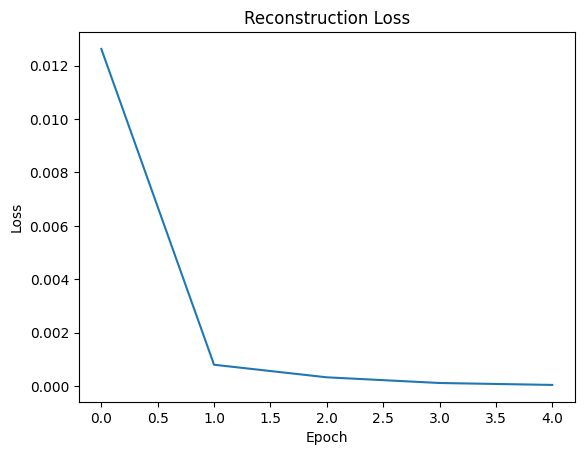

In [30]:

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Reconstruction Loss")
plt.show()


## Reconstruction + Metrics

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.118804805..0.102115154].


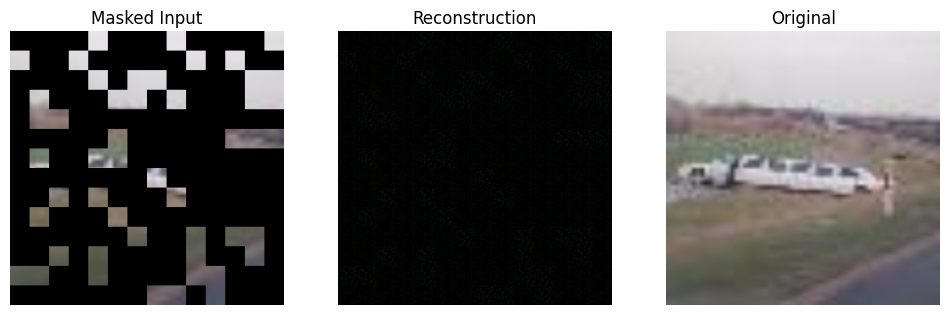

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1187622..0.102184586].


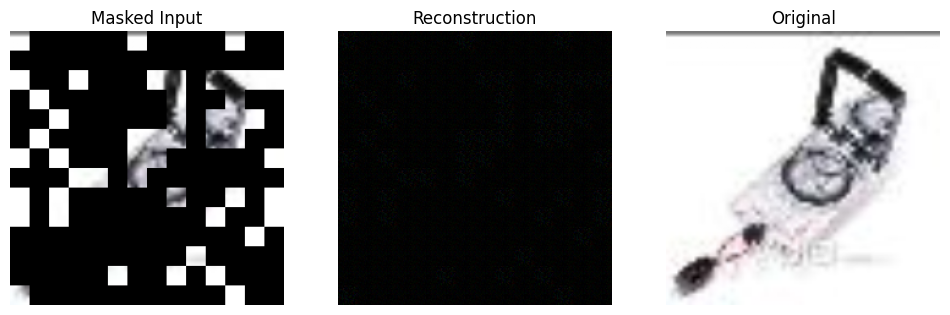

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.11881443..0.10214275].


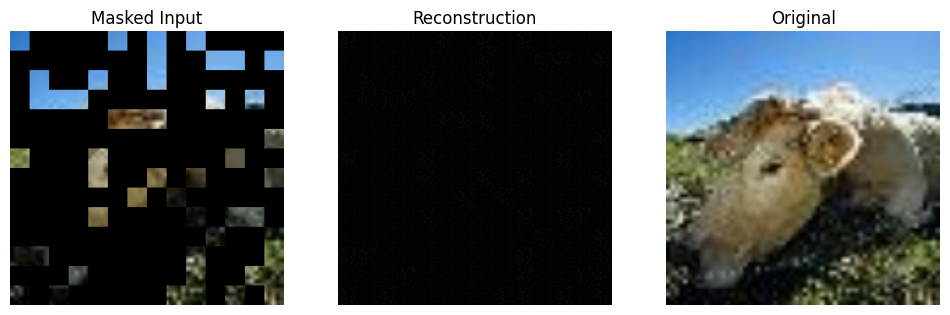

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.11884115..0.10206732].


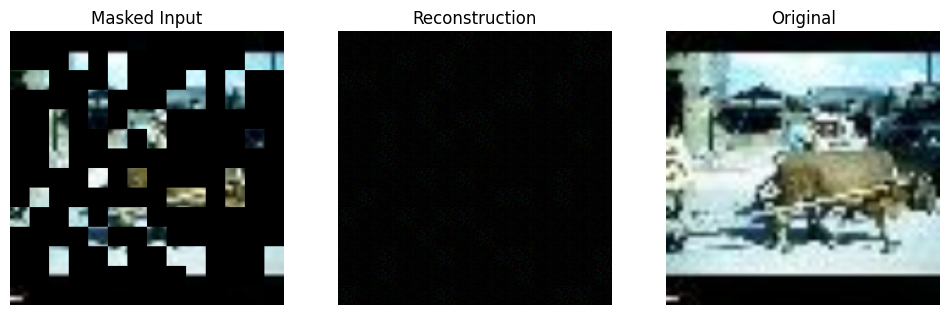

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.11876302..0.102082424].


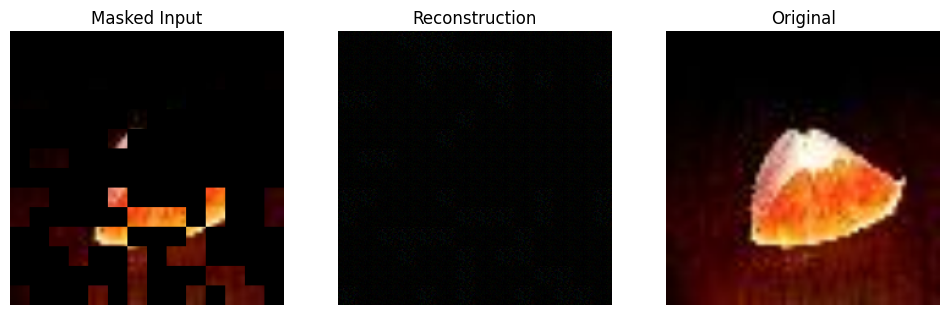

Average PSNR: 5.2811805486679075
Average SSIM: 0.05213689


In [31]:
model.eval()

psnr_scores = []
ssim_scores = []

with torch.no_grad():

    imgs,_ = next(iter(dataloader))
    imgs = imgs.to(device)

    pred, mask = model(imgs)

    recon = unpatchify(pred)

    # -------- Create Masked Images --------
    B = imgs.shape[0]
    patch_size = 16
    img_size = 224
    num_patches = img_size // patch_size

    mask_img = mask.reshape(B, num_patches, num_patches)

    mask_img = mask_img.repeat_interleave(patch_size,1).repeat_interleave(patch_size,2)

    mask_img = mask_img.unsqueeze(1)

    masked_imgs = imgs * (1 - mask_img)

    # -------- Visualization --------

    for i in range(5):

        psnr_scores.append(calculate_psnr(recon[i], imgs[i]))
        ssim_scores.append(calculate_ssim(recon[i], imgs[i]))

        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.title("Masked Input")
        plt.imshow(masked_imgs[i].cpu().permute(1,2,0))
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Reconstruction")
        plt.imshow(recon[i].cpu().permute(1,2,0))
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.title("Original")
        plt.imshow(imgs[i].cpu().permute(1,2,0))
        plt.axis("off")

        plt.show()

print("Average PSNR:", sum(psnr_scores)/len(psnr_scores))
print("Average SSIM:", sum(ssim_scores)/len(ssim_scores))

In [33]:
torch.save(model.state_dict(), "mae_model.pth")